# ENEM 2024 · Redação × Perfil do participante — análise exploratória

**Objetivo do trabalho:** prever o desempenho do participante a partir do seu perfil socioeconômico e entender quais fatores mais pesam.

Este notebook faz a **análise exploratória inicial** da base que usaremos para isso: o *merge* entre

| arquivo | chave | conteúdo |
|---|---|---|
| `PARTICIPANTES_2024.csv` | `NU_INSCRICAO` | perfil (idade, sexo, cor/raça, conclusão do EM, UF) + questionário socioeconômico Q001–Q023 |
| `COMPETENCIAS_REDACAO_2024.csv` | `NU_INSCRICAO` | situação e nota da redação, 5 competências, notas de cada corretor |

> **Por que não usamos `RESULTADOS_2024`?** Segundo o Leia-Me do INEP, `PARTICIPANTES` e `RESULTADOS` **não têm chave em comum** (LGPD): `NU_SEQUENCIAL` não é `NU_INSCRICAO`. Um merge entre as duas não casa nenhuma linha. Já o complemento de redação usa `NU_INSCRICAO` e casa 100% com `PARTICIPANTES`.

Regra do Lab 03 continua valendo: ao comparar grupos, sempre **centro, dispersão e tamanho**.

## Passo 0 · configuração e leitura

Os arquivos são grandes (≈ 4,3 milhões de linhas cada). Para caber na memória do Colab:
- lemos **só as colunas necessárias** (`usecols`);
- variáveis categóricas como `category` (1 byte por valor em vez de uma string);
- notas como `float32`.

No Colab, suba os dois CSVs para `/content` **ou** monte o Drive e ajuste `DATA_DIR`. Confira o número de linhas depois de ler — um upload interrompido gera uma base truncada sem aviso.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})

# from google.colab import drive; drive.mount("/content/drive")
DATA_DIR = os.environ.get("ENEM_DIR", "/content")          # ajuste se usar o Drive
PART_PATH = os.path.join(DATA_DIR, "PARTICIPANTES_2024.csv")
RED_PATH  = os.path.join(DATA_DIR, "COMPETENCIAS_REDACAO_2024.csv")

In [2]:
PERFIL = ["TP_FAIXA_ETARIA", "TP_SEXO", "TP_ESTADO_CIVIL", "TP_COR_RACA", "TP_NACIONALIDADE",
          "TP_ST_CONCLUSAO", "TP_ANO_CONCLUIU", "TP_ENSINO", "IN_TREINEIRO", "SG_UF_PROVA"]
QUESTOES = [f"Q{i:03d}" for i in range(1, 24)]
CATEG = PERFIL + QUESTOES

part = pd.read_csv(PART_PATH, sep=";", encoding="latin1",
                   usecols=["NU_INSCRICAO"] + CATEG,
                   dtype={c: "category" for c in CATEG})

COMP    = [f"NU_NOTA_COMP{k}" for k in range(1, 6)]
AV_NOTA = ["NU_NOTA_AV1", "NU_NOTA_AV2", "NU_NOTA_AV3", "NU_NOTA_AV4"]
COMP_AV = [f"NU_NOTA_COMP{k}_AV{a}" for k in range(1, 6) for a in (1, 2)]
RED_COLS = ["NU_INSCRICAO", "TP_STATUS_REDACAO", "NU_NOTA_REDACAO"] + COMP + AV_NOTA + COMP_AV

red = pd.read_csv(RED_PATH, sep=";", encoding="latin1", usecols=RED_COLS,
                  dtype={c: "float32" for c in RED_COLS if c != "NU_INSCRICAO"})

print("PARTICIPANTES:", part.shape)
print("REDAÇÃO      :", red.shape)

PARTICIPANTES: (4332944, 34)
REDAÇÃO      : (4332944, 22)


## Passo 1 · o merge

Antes de juntar, conferimos que a chave é **única** nos dois lados. Usamos `validate="one_to_one"` (o pandas dá erro se não for) e `indicator=True` para ver quantas linhas casaram.

In [3]:
print("NU_INSCRICAO único em PARTICIPANTES:", part["NU_INSCRICAO"].is_unique)
print("NU_INSCRICAO único em REDAÇÃO      :", red["NU_INSCRICAO"].is_unique)

df = part.merge(red, on="NU_INSCRICAO", how="outer", validate="one_to_one", indicator=True)
print(df["_merge"].value_counts())

df = df.drop(columns="_merge")
del part, red
print("\nBase unida:", df.shape, f"— {df.memory_usage(deep=True).sum() / 1e9:.2f} GB em memória")
df.head()

NU_INSCRICAO único em PARTICIPANTES: True


NU_INSCRICAO único em REDAÇÃO      : True


_merge
both          4332944
left_only           0
right_only          0
Name: count, dtype: int64

Base unida: (4332944, 55) — 0.54 GB em memória


,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,NU_NOTA_AV1,NU_NOTA_COMP1_AV1,NU_NOTA_COMP2_AV1,NU_NOTA_COMP3_AV1,NU_NOTA_COMP4_AV1,NU_NOTA_COMP5_AV1,NU_NOTA_AV2,NU_NOTA_COMP1_AV2,NU_NOTA_COMP2_AV2,NU_NOTA_COMP3_AV2,NU_NOTA_COMP4_AV2,NU_NOTA_COMP5_AV2,NU_NOTA_AV3,NU_NOTA_AV4
0,210062064233,5,F,1,1,1,1,3,NaN,0,RS,F,F,C,D,4,B,C,A,C,D,C,B,B,A,B,B,B,D,A,B,B,E,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,210062064234,11,F,1,1,1,1,10,NaN,0,RS,B,C,A,D,2,B,E,A,B,B,B,B,B,A,A,A,A,B,A,B,A,C,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,210062064235,11,F,1,1,1,1,9,NaN,0,RS,H,F,F,D,5,B,J,A,C,D,B,B,C,A,B,B,B,D,B,B,A,D,A,1.0,100.0,100.0,80.0,120.0,120.0,520.0,480.0,80.0,80.0,80.0,120.0,120.0,560.0,120.0,120.0,80.0,120.0,120.0,NaN,NaN
3,210062064236,3,F,1,3,1,2,0,1,0,RS,B,B,B,B,6,A,C,A,B,C,B,A,B,A,B,A,A,A,A,B,A,D,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,210062064237,16,M,3,1,1,1,18,NaN,0,RS,B,B,C,C,2,A,A,A,B,C,A,A,B,A,A,A,A,B,A,B,A,B,A,1.0,120.0,120.0,120.0,120.0,140.0,620.0,600.0,120.0,120.0,120.0,120.0,120.0,640.0,120.0,120.0,120.0,120.0,160.0,NaN,NaN


## Passo 2 · rótulos

Os códigos vêm do dicionário do INEP (`Dicionário_Microdados_Enem_2024.xlsx` e `Dicionário_Competencias_Redacao_2024.xlsx`). Guardamos só os que usaremos nos gráficos. **Atenção:** em 2024, `Q006` é *"Você possui renda?"*; a **renda familiar é a `Q007`**.

In [4]:
ROT = {
    "TP_SEXO": {"F": "Feminino", "M": "Masculino"},
    "TP_COR_RACA": {"0": "Não declarado", "1": "Branca", "2": "Preta", "3": "Parda",
                    "4": "Amarela", "5": "Indígena", "6": "Sem informação"},
    "TP_ST_CONCLUSAO": {"1": "Já concluiu", "2": "Conclui em 2024",
                        "3": "Conclui após 2024", "4": "Não concluiu/não cursa"},
    "IN_TREINEIRO": {"0": "Não", "1": "Treineiro"},
    "TP_FAIXA_ETARIA": {"1": "<17", "2": "17", "3": "18", "4": "19", "5": "20", "6": "21", "7": "22",
                        "8": "23", "9": "24", "10": "25", "11": "26-30", "12": "31-35", "13": "36-40",
                        "14": "41-45", "15": "46-50", "16": "51-55", "17": "56-60", "18": "61-65",
                        "19": "66-70", "20": ">70"},
    # escolaridade do pai (Q001) e da mãe (Q002)
    "Q002": {"A": "Nunca estudou", "B": "Fund. I incompleto", "C": "Fund. I completo",
             "D": "Fund. II completo", "E": "Médio completo", "F": "Superior completo",
             "G": "Pós-graduação", "H": "Não sei"},
    "Q007": {"A": "Nenhuma", "B": "até 1,4k", "C": "1,4–2,1k", "D": "2,1–2,8k", "E": "2,8–3,5k",
             "F": "3,5–4,2k", "G": "4,2–5,6k", "H": "5,6–7,1k", "I": "7,1–8,5k", "J": "8,5–9,9k",
             "K": "9,9–11,3k", "L": "11,3–12,7k", "M": "12,7–14,1k", "N": "14,1–16,9k",
             "O": "16,9–21,2k", "P": "21,2–28,2k", "Q": "> 28,2k"},
    "Q020": {"A": "Sem wi-fi", "B": "Com wi-fi"},
    "Q021": {"A": "Nenhum", "B": "1", "C": "2", "D": "3", "E": "4+"},
    "Q023": {"A": "Só pública", "B": "Pública + privada s/ bolsa", "C": "Pública + privada c/ bolsa",
             "D": "Só privada s/ bolsa", "E": "Só privada c/ bolsa", "F": "Não frequentou"},
    "TP_STATUS_REDACAO": {1: "Sem problemas", 2: "Anulada", 3: "Cópia do texto motivador",
                          4: "Em branco", 6: "Fuga ao tema", 7: "Não atende tipo textual",
                          8: "Texto insuficiente", 9: "Parte desconectada"},
}
ROT["Q001"] = ROT["Q002"]

def ordem_codigos(serie):
    # ordena códigos numéricos como número e letras em ordem alfabética
    cats = [c for c in serie.cat.categories]
    return sorted(cats, key=lambda x: (0, int(x)) if str(x).isdigit() else (1, str(x)))

## Passo 3 · valores ausentes

Aqui ausência **tem significado** — por isso **não imputamos**:
- `NU_NOTA_REDACAO` ausente → o participante **não fez a redação** (faltou ou foi eliminado);
- `NU_NOTA_AV3` / `AV4` ausentes → não precisou de 3º corretor / banca;
- `TP_ENSINO` só é preenchido para quem já concluiu o EM.

In [5]:
aus = (df.isna().mean() * 100).round(1)
aus[aus > 0].sort_values(ascending=False).to_frame("% ausente")

,% ausente
NU_NOTA_AV4,96.0
NU_NOTA_AV3,76.0
TP_ENSINO,64.3
NU_NOTA_COMP2,26.9
NU_NOTA_COMP1,26.9
TP_STATUS_REDACAO,26.9
NU_NOTA_COMP4,26.9
NU_NOTA_COMP3,26.9
NU_NOTA_COMP5,26.9
NU_NOTA_REDACAO,26.9


## Passo 4 · quem fez a redação?

Antes de olhar notas: **quem ficou de fora** da base de notas? Se a ausência não for aleatória (e não é), isso limita o que o modelo aprende.

In [6]:
df["fez_redacao"] = df["NU_NOTA_REDACAO"].notna()
print(f"Inscritos: {len(df):,}  |  fizeram a redação: {df['fez_redacao'].sum():,} "
      f"({df['fez_redacao'].mean():.1%})")

def taxa(col):
    t = (df.groupby(col, observed=True)["fez_redacao"]
           .agg(inscritos="size", taxa_presenca="mean"))
    t["taxa_presenca"] = (t["taxa_presenca"] * 100).round(1)
    t = t.reindex([c for c in ordem_codigos(df[col]) if c in t.index])
    t.index = t.index.map(lambda x: ROT.get(col, {}).get(x, x))
    return t

for col in ["IN_TREINEIRO", "TP_ST_CONCLUSAO", "TP_SEXO"]:
    display(taxa(col))

Inscritos: 4,332,944  |  fizeram a redação: 3,167,955 (73.1%)


,inscritos,taxa_presenca
IN_TREINEIRO,,
Não,3488685,69.6
Treineiro,844259,87.8


,inscritos,taxa_presenca
TP_ST_CONCLUSAO,,
Já concluiu,1846311,60.8
Conclui em 2024,1617602,79.6
Conclui após 2024,844259,87.8
Não concluiu/não cursa,24772,64.7


,inscritos,taxa_presenca
TP_SEXO,,
Feminino,2624621,73.8
Masculino,1708323,72.0


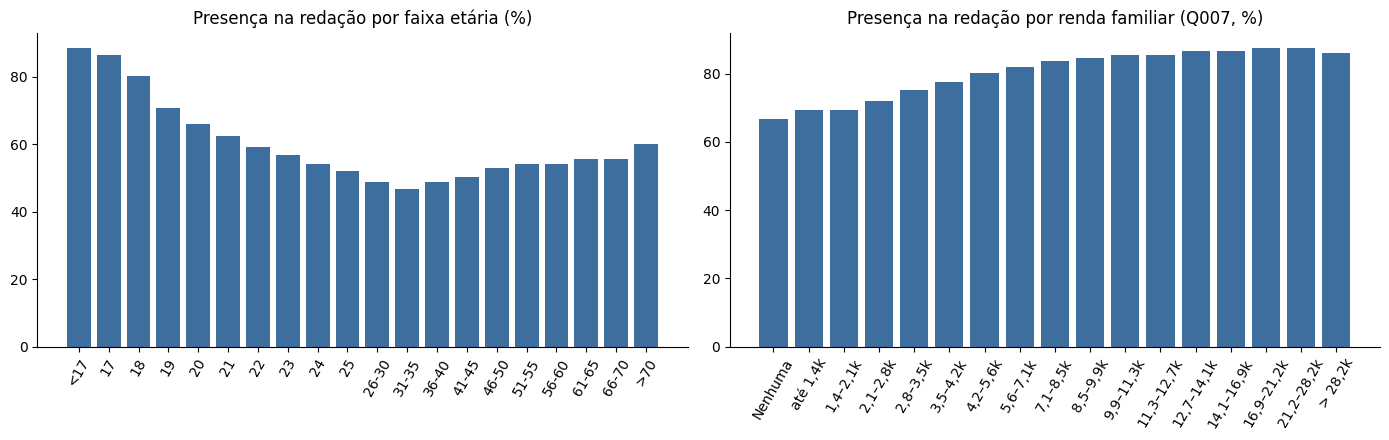

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

t = taxa("TP_FAIXA_ETARIA")
axes[0].bar(t.index, t["taxa_presenca"], color="#3E6E9E")
axes[0].set_title("Presença na redação por faixa etária (%)")
axes[0].tick_params(axis="x", rotation=60)

t = taxa("Q007")
axes[1].bar(t.index, t["taxa_presenca"], color="#3E6E9E")
axes[1].set_title("Presença na redação por renda familiar (Q007, %)")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout(); plt.show()

## Passo 5 · situação da redação

Entre quem fez a prova, nem toda redação foi corrigida normalmente. Status diferente de *Sem problemas* recebe **nota zero** — isso gera uma massa de zeros que não tem a ver com "escrever mal".

In [8]:
fez = df[df["fez_redacao"]]
st = fez["TP_STATUS_REDACAO"].value_counts().rename(index=ROT["TP_STATUS_REDACAO"]).to_frame("participantes")
st["%"] = (st["participantes"] / st["participantes"].sum() * 100).round(2)
display(st)

print("Notas zero:", (fez["NU_NOTA_REDACAO"] == 0).sum(),
      "| delas, com status ≠ 'Sem problemas':",
      ((fez["NU_NOTA_REDACAO"] == 0) & (fez["TP_STATUS_REDACAO"] != 1)).sum())
print("Notas 1000:", (fez["NU_NOTA_REDACAO"] == 1000).sum())

,participantes,%
TP_STATUS_REDACAO,,
Sem problemas,3002710,94.78
Em branco,89792,2.83
Fuga ao tema,33354,1.05
Cópia do texto motivador,17724,0.56
Texto insuficiente,14387,0.45
Parte desconectada,4397,0.14
Não atende tipo textual,3159,0.10
Anulada,2432,0.08


Notas zero: 165245 | delas, com status ≠ 'Sem problemas': 165245
Notas 1000: 12


## Passo 6 · distribuição da nota

Olhamos uma variável de cada vez **antes** de cruzar. As notas são múltiplos de 20 (média de dois corretores que dão 0/40/80/…/200 por competência), então usamos *bins* de 20 pontos.

,todas que fizeram,status sem problemas
count,3167955.0,3002710.0
mean,624.6,659.0
std,216.3,163.5
min,0.0,40.0
25%,520.0,540.0
50%,640.0,640.0
75%,780.0,800.0
max,1000.0,1000.0


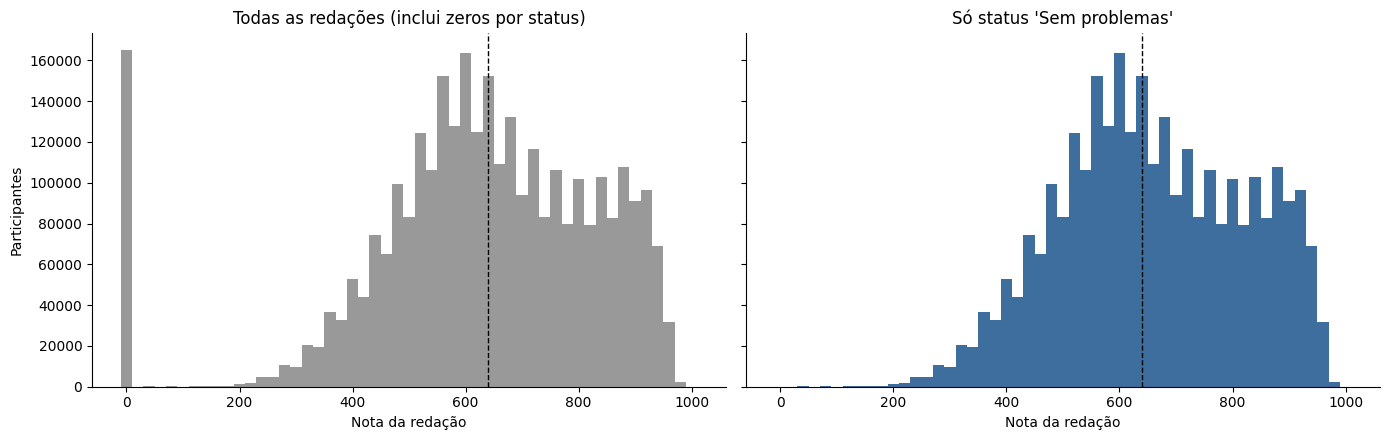

In [9]:
ok = fez.loc[fez["TP_STATUS_REDACAO"] == 1, RED_COLS[1:]]   # redações corrigidas normalmente (só colunas de nota)

display(pd.DataFrame({
    "todas que fizeram": fez["NU_NOTA_REDACAO"].describe(),
    "status sem problemas": ok["NU_NOTA_REDACAO"].describe(),
}).round(1))

bins = np.arange(-10, 1011, 20)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
axes[0].hist(fez["NU_NOTA_REDACAO"], bins=bins, color="#999")
axes[0].set_title("Todas as redações (inclui zeros por status)")
axes[1].hist(ok["NU_NOTA_REDACAO"], bins=bins, color="#3E6E9E")
axes[1].set_title("Só status 'Sem problemas'")
for ax in axes:
    ax.set_xlabel("Nota da redação"); ax.axvline(ok["NU_NOTA_REDACAO"].median(), ls="--", c="k", lw=1)
axes[0].set_ylabel("Participantes")
plt.tight_layout(); plt.show()

## Passo 7 · as cinco competências

C1 norma culta · C2 compreensão da proposta · C3 argumentação · C4 coesão · C5 proposta de intervenção.

Vemos (a) como cada competência se distribui e (b) quanto elas andam juntas — se forem muito correlacionadas, prever a nota total já captura quase tudo.

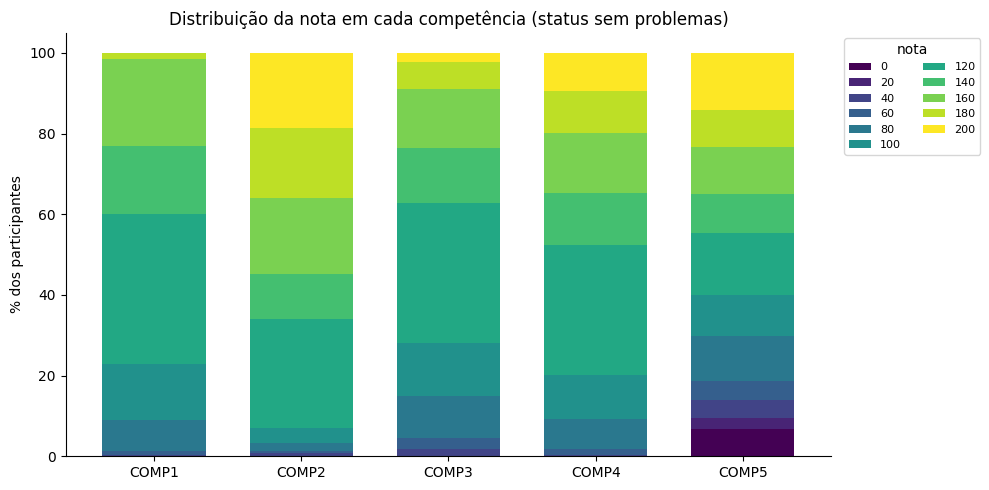

,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
mean,126.199997,152.500000,124.400002,136.0,119.800003,659.0
median,120.000000,160.000000,120.000000,120.0,120.000000,640.0
std,25.700001,34.900002,33.099998,35.5,58.099998,163.5


In [10]:
dist = pd.DataFrame({c.replace("NU_NOTA_", ""): ok[c].value_counts(normalize=True).sort_index() * 100
                     for c in COMP}).fillna(0)
dist.index = dist.index.astype(int)

ax = dist.T.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="viridis", width=0.7)
ax.set_ylabel("% dos participantes"); ax.set_title("Distribuição da nota em cada competência (status sem problemas)")
ax.legend(title="nota", bbox_to_anchor=(1.01, 1), loc="upper left", ncol=2, fontsize=8)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

ok[COMP + ["NU_NOTA_REDACAO"]].agg(["mean", "median", "std"]).round(1)

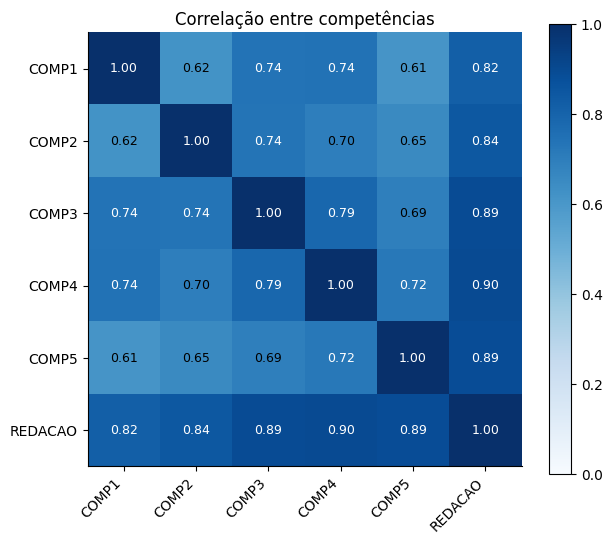

In [11]:
corr = ok[COMP + ["NU_NOTA_REDACAO"]].corr()
labels = [c.replace("NU_NOTA_", "") for c in corr.columns]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if corr.iloc[i, j] > 0.7 else "black", fontsize=9)
fig.colorbar(im, ax=ax); ax.set_title("Correlação entre competências")
plt.tight_layout(); plt.show()

## Passo 8 · nota × perfil

Agora o cruzamento que interessa ao modelo. Para cada variável: **alunos, média, mediana, desvio** e a participação do grupo.

Usamos `fez` (todos que fizeram a redação, inclusive zeros), porque é essa nota que o modelo terá de prever. O boxplot é desenhado a partir de quantis por grupo (`ax.bxp`) — mais leve do que passar 3 milhões de pontos.

In [12]:
ALVO = "NU_NOTA_REDACAO"

def resumo(col, base=fez, alvo=ALVO):
    g = base[[col, alvo]].astype({alvo: "float64"}).groupby(col, observed=True)[alvo]
    t = g.agg(alunos="count", media="mean", mediana="median", desvio="std").round(1)
    t["% alunos"] = (t["alunos"] / t["alunos"].sum() * 100).round(1)
    t = t.reindex([c for c in ordem_codigos(base[col]) if c in t.index])
    t.index = t.index.map(lambda x: ROT.get(col, {}).get(x, x))
    return t

def boxplot_por(col, titulo, base=fez, alvo=ALVO, ax=None, rot=0):
    q = base.groupby(col, observed=True)[alvo].quantile([.05, .25, .5, .75, .95]).unstack()
    q = q.reindex([c for c in ordem_codigos(base[col]) if c in q.index])
    stats = [{"label": ROT.get(col, {}).get(k, k), "whislo": r[.05], "q1": r[.25], "med": r[.5],
              "q3": r[.75], "whishi": r[.95], "fliers": []} for k, r in q.iterrows()]
    ax = ax or plt.subplots(figsize=(10, 4.5))[1]
    ax.bxp(stats, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="#BFD3E6"), medianprops=dict(color="#06406F", lw=2))
    ax.set_title(titulo + "  (bigodes = p5–p95)"); ax.set_ylabel("Nota da redação")
    ax.tick_params(axis="x", rotation=rot)
    return ax

### 8.1 Renda familiar (Q007)

,alunos,media,mediana,desvio,% alunos
Q007,,,,,
Nenhuma,261569,520.3,540.0,231.4,8.3
"até 1,4k",990842,568.2,580.0,222.8,31.3
"1,4–2,1k",526218,609.3,620.0,204.9,16.6
"2,1–2,8k",238175,634.2,640.0,199.2,7.5
"2,8–3,5k",231193,653.0,660.0,195.8,7.3
"3,5–4,2k",179470,670.2,680.0,192.7,5.7
"4,2–5,6k",174548,688.7,700.0,187.8,5.5
"5,6–7,1k",143593,705.7,720.0,183.6,4.5
"7,1–8,5k",68543,719.3,740.0,180.3,2.2


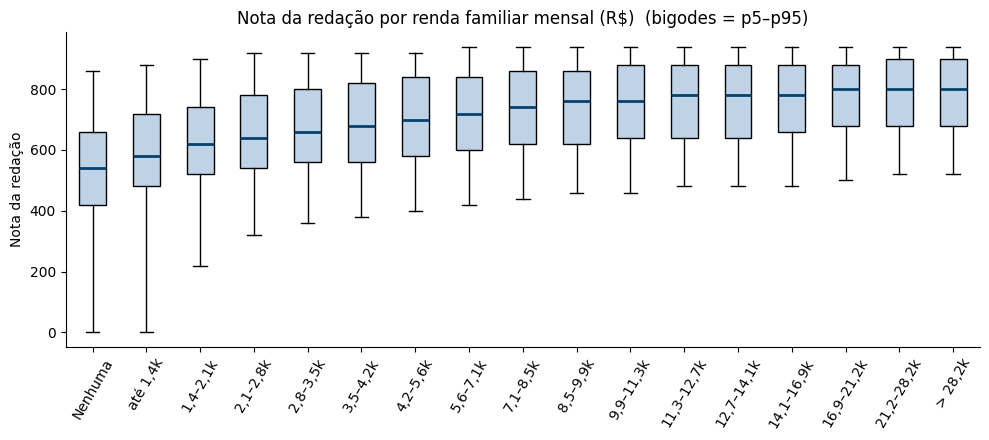

In [13]:
display(resumo("Q007"))
boxplot_por("Q007", "Nota da redação por renda familiar mensal (R$)", rot=60)
plt.tight_layout(); plt.show()

### 8.2 Escolaridade da mãe (Q002) e do pai (Q001)

,alunos,media,mediana,desvio,% alunos
Q002,,,,,
Nunca estudou,65262,499.1,520.0,226.5,2.1
Fund. I incompleto,291612,547.1,560.0,216.0,9.2
Fund. I completo,269889,568.1,580.0,218.2,8.5
Fund. II completo,416008,581.8,600.0,217.2,13.1
Médio completo,1157152,627.4,640.0,208.1,36.5
Superior completo,419752,699.8,720.0,190.7,13.2
Pós-graduação,436571,717.9,740.0,187.4,13.8
Não sei,111709,519.4,560.0,237.6,3.5


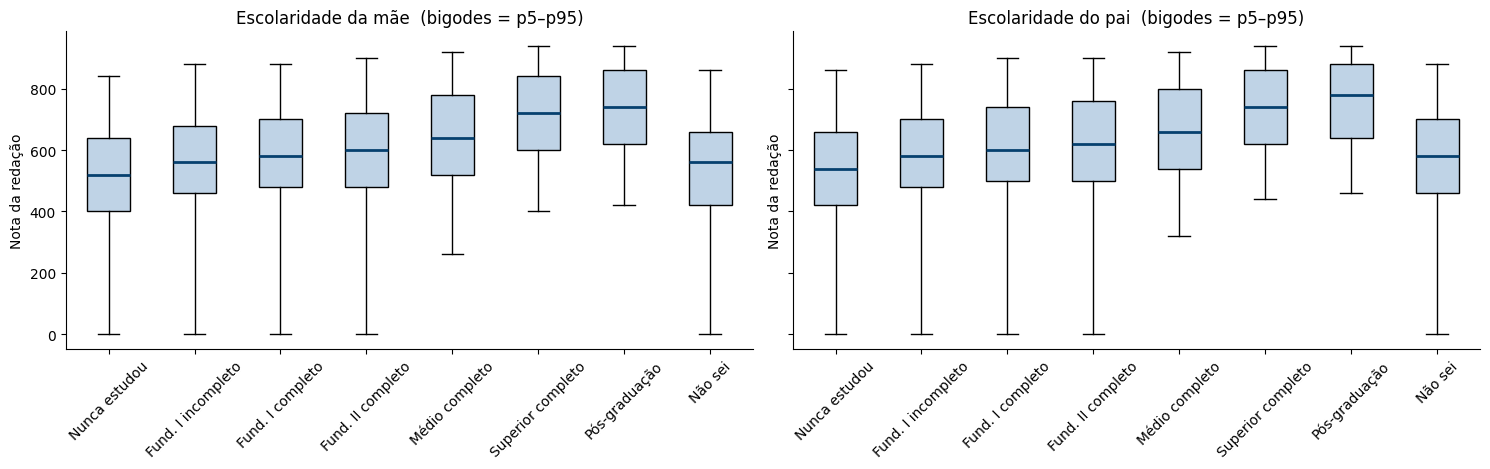

In [14]:
display(resumo("Q002"))
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=True)
boxplot_por("Q002", "Escolaridade da mãe", ax=axes[0], rot=45)
boxplot_por("Q001", "Escolaridade do pai", ax=axes[1], rot=45)
plt.tight_layout(); plt.show()

### 8.3 Tipo de escola no Ensino Médio (Q023)

,alunos,media,mediana,desvio,% alunos
Q023,,,,,
Só pública,2281620,584.5,600.0,216.2,72.0
Pública + privada s/ bolsa,122405,636.1,640.0,201.5,3.9
Pública + privada c/ bolsa,60123,653.7,660.0,191.0,1.9
Só privada s/ bolsa,553520,754.8,780.0,165.3,17.5
Só privada c/ bolsa,141639,743.0,760.0,163.7,4.5
Não frequentou,8648,577.4,600.0,220.3,0.3


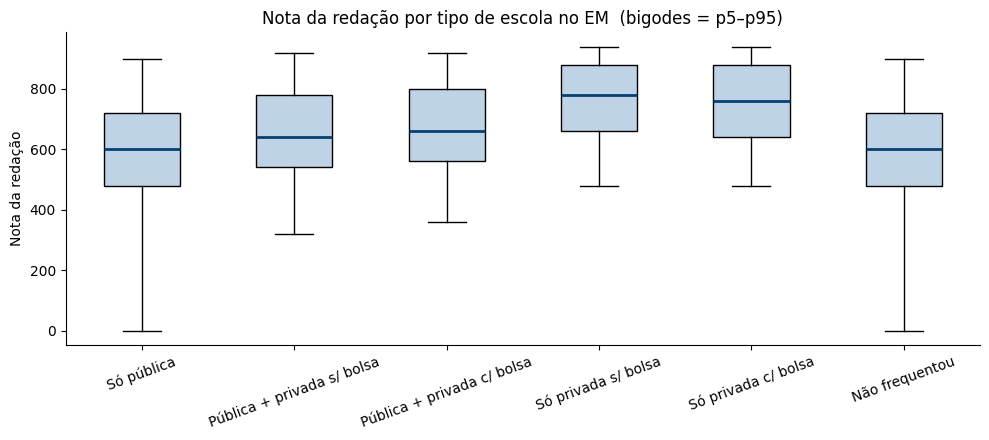

In [15]:
display(resumo("Q023"))
boxplot_por("Q023", "Nota da redação por tipo de escola no EM", rot=20)
plt.tight_layout(); plt.show()

### 8.4 Cor/raça, sexo e situação de conclusão

Diferenças entre grupos aqui **se misturam com renda e escola** (confusão). A EDA mostra a associação; separar os efeitos é trabalho do modelo.

In [16]:
for col in ["TP_COR_RACA", "TP_SEXO", "TP_ST_CONCLUSAO", "IN_TREINEIRO"]:
    display(resumo(col))

,alunos,media,mediana,desvio,% alunos
TP_COR_RACA,,,,,
Não declarado,34023,605.0,620.0,229.5,1.1
Branca,1368469,668.2,680.0,203.5,43.2
Preta,365536,578.5,600.0,212.6,11.5
Parda,1336095,595.2,600.0,221.1,42.2
Amarela,45106,607.3,620.0,222.1,1.4
Indígena,18726,513.2,540.0,227.7,0.6


,alunos,media,mediana,desvio,% alunos
TP_SEXO,,,,,
Feminino,1937747,642.2,660.0,212.5,61.2
Masculino,1230208,596.9,600.0,219.4,38.8


,alunos,media,mediana,desvio,% alunos
TP_ST_CONCLUSAO,,,,,
Já concluiu,1123162,631.7,620.0,203.9,35.5
Conclui em 2024,1287456,621.5,640.0,224.3,40.6
Conclui após 2024,741304,620.3,640.0,219.9,23.4
Não concluiu/não cursa,16033,574.3,600.0,231.9,0.5


,alunos,media,mediana,desvio,% alunos
IN_TREINEIRO,,,,,
Não,2426651,625.9,640.0,215.2,76.6
Treineiro,741304,620.3,640.0,219.9,23.4


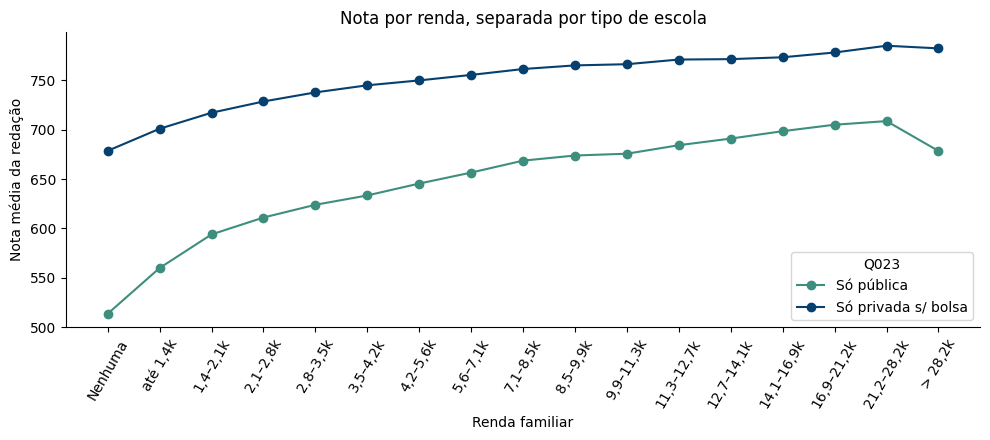

Q007,Nenhuma,"até 1,4k","1,4–2,1k","2,1–2,8k","2,8–3,5k","3,5–4,2k","4,2–5,6k","5,6–7,1k","7,1–8,5k","8,5–9,9k","9,9–11,3k","11,3–12,7k","12,7–14,1k","14,1–16,9k","16,9–21,2k","21,2–28,2k","> 28,2k"
Q023,,,,,,,,,,,,,,,,,
Só pública,244269,904229,437526,179582,158291,109620,91214,62692,26062,17581,18072,7420,7166,6342,6122,2815,2617
Só privada s/ bolsa,5478,23755,33947,27890,38742,41629,53823,56751,31130,27514,40564,19475,21738,25708,35442,25579,44355


In [17]:
# renda × tipo de escola: a diferença pública/privada persiste dentro da mesma faixa de renda?
sub = fez.loc[fez["Q023"].isin(["A", "D"]), ["Q007", "Q023", ALVO]]
tab = (sub.groupby(["Q007", "Q023"], observed=True)[ALVO].agg(["mean", "count"])
          .unstack("Q023"))
media = tab["mean"].rename(columns={"A": "Só pública", "D": "Só privada s/ bolsa"})
n = tab["count"].rename(columns={"A": "Só pública", "D": "Só privada s/ bolsa"})
media.index = media.index.map(ROT["Q007"])

ax = media.plot(marker="o", figsize=(10, 4.5), color=["#3E8E7E", "#06406F"])
ax.set_ylabel("Nota média da redação"); ax.set_xlabel("Renda familiar")
ax.set_title("Nota por renda, separada por tipo de escola")
ax.set_xticks(range(len(media)), media.index, rotation=60)
plt.tight_layout(); plt.show()
n.index = media.index
n.T

### 8.5 Unidade da Federação (local da prova)

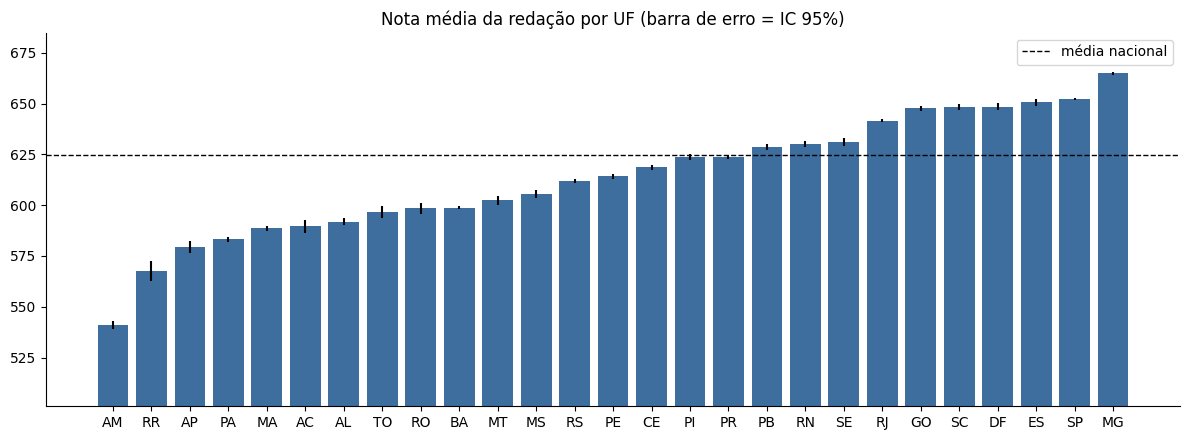

,alunos,media,mediana,desvio
SG_UF_PROVA,,,,
MG,293350,664.8,680.0,198.1
SP,488738,652.3,660.0,183.5
ES,55229,650.6,660.0,214.6
DF,55485,648.5,660.0,199.0
SC,70683,648.3,660.0,197.6
GO,109657,647.7,660.0,210.1
RJ,213345,641.6,640.0,210.6
SE,54338,630.9,660.0,230.9
RN,78857,630.2,640.0,214.6


In [18]:
uf = resumo("SG_UF_PROVA").sort_values("media")
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(uf.index, uf["media"], yerr=uf["desvio"] / np.sqrt(uf["alunos"]) * 1.96, color="#3E6E9E")
ax.axhline(fez[ALVO].mean(), ls="--", c="k", lw=1, label="média nacional")
ax.set_ylim(uf["media"].min() - 40, uf["media"].max() + 20)
ax.set_title("Nota média da redação por UF (barra de erro = IC 95%)"); ax.legend()
plt.tight_layout(); plt.show()
uf.sort_values("media", ascending=False)[["alunos", "media", "mediana", "desvio"]]

## Passo 9 · qual variável explica mais, sozinha?

Para escolher *features*, medimos para cada variável o **η² (eta ao quadrado)**: a fração da variância da nota explicada pelas médias dos grupos daquela variável (é o R² de um modelo que só usa aquela variável). Fazemos o mesmo para a **presença** (`fez_redacao`).

- η² = 0 → a variável não separa as notas;
- η² alto → os grupos têm médias bem diferentes.

> Variáveis altamente correlacionadas entre si (renda, bens da casa, escolaridade dos pais) medem quase a mesma coisa — os η² **não se somam**.

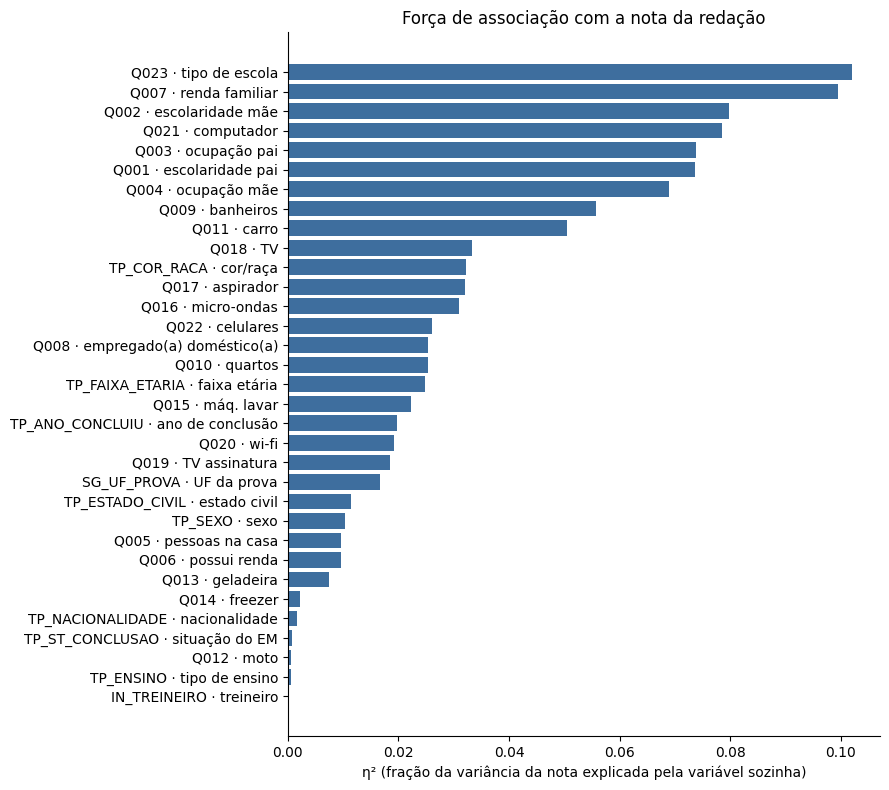

,descricao,eta2_nota,eta2_presenca
Q023,tipo de escola,0.102,0.025
Q007,renda familiar,0.099,0.018
Q002,escolaridade mãe,0.080,0.032
Q021,computador,0.078,0.012
Q003,ocupação pai,0.074,0.017
Q001,escolaridade pai,0.074,0.026
Q004,ocupação mãe,0.069,0.018
Q009,banheiros,0.056,0.016
Q011,carro,0.051,0.014
Q018,TV,0.033,0.009


In [19]:
def eta2(base, col, alvo):
    y = base[alvo].astype("float64")
    m = base.groupby(col, observed=True)[alvo].transform("mean").astype("float64").fillna(y.mean())
    return ((m - y.mean()) ** 2).mean() / y.var(ddof=0)

df["fez_redacao_num"] = df["fez_redacao"].astype("float32")
DESCR = {"Q001": "escolaridade pai", "Q002": "escolaridade mãe", "Q003": "ocupação pai",
         "Q004": "ocupação mãe", "Q005": "pessoas na casa", "Q006": "possui renda",
         "Q007": "renda familiar", "Q008": "empregado(a) doméstico(a)", "Q009": "banheiros",
         "Q010": "quartos", "Q011": "carro", "Q012": "moto", "Q013": "geladeira",
         "Q014": "freezer", "Q015": "máq. lavar", "Q016": "micro-ondas", "Q017": "aspirador",
         "Q018": "TV", "Q019": "TV assinatura", "Q020": "wi-fi", "Q021": "computador",
         "Q022": "celulares", "Q023": "tipo de escola",
         "TP_FAIXA_ETARIA": "faixa etária", "TP_SEXO": "sexo", "TP_ESTADO_CIVIL": "estado civil",
         "TP_COR_RACA": "cor/raça", "TP_NACIONALIDADE": "nacionalidade", "TP_ST_CONCLUSAO": "situação do EM",
         "TP_ANO_CONCLUIU": "ano de conclusão", "TP_ENSINO": "tipo de ensino", "IN_TREINEIRO": "treineiro",
         "SG_UF_PROVA": "UF da prova"}

forca = pd.DataFrame({
    "descricao": [DESCR.get(c, c) for c in CATEG],
    "eta2_nota": [eta2(fez, c, ALVO) for c in CATEG],
    "eta2_presenca": [eta2(df, c, "fez_redacao_num") for c in CATEG],
}, index=CATEG).sort_values("eta2_nota", ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
lab = [f"{i} · {d}" for i, d in zip(forca.index, forca["descricao"])]
ax.barh(lab[::-1], forca["eta2_nota"][::-1], color="#3E6E9E")
ax.set_xlabel("η² (fração da variância da nota explicada pela variável sozinha)")
ax.set_title("Força de associação com a nota da redação")
plt.tight_layout(); plt.show()
forca.round(3)

## Passo 10 · os corretores

Cada redação tem 2 corretores; se discordarem demais, vai para um 3º e, se persistir, para uma banca. Isso mostra o **ruído do próprio alvo**: nenhum modelo vai prever a nota com erro menor que a discordância entre corretores humanos.

|AV1 − AV2|: média 86.7, mediana 80; > 100 pontos em 33.3%
Correlação AV1 × AV2 (nota total): 0.779
Foram para 3º corretor: 33.9%  |  para banca: 5.5%


,C1,C2,C3,C4,C5
corr AV1×AV2,0.48,0.55,0.55,0.61,0.78
% notas iguais,54.90,51.51,47.90,48.99,48.14


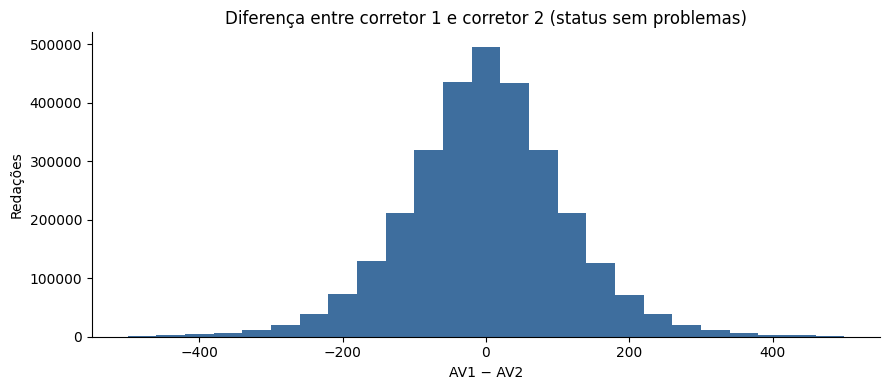

In [20]:
dif = (ok["NU_NOTA_AV1"] - ok["NU_NOTA_AV2"]).abs()
print(f"|AV1 − AV2|: média {dif.mean():.1f}, mediana {dif.median():.0f}; > 100 pontos em {(dif > 100).mean():.1%}")
print(f"Correlação AV1 × AV2 (nota total): {ok['NU_NOTA_AV1'].corr(ok['NU_NOTA_AV2']):.3f}")
print(f"Foram para 3º corretor: {ok['NU_NOTA_AV3'].notna().mean():.1%}  |  para banca: {ok['NU_NOTA_AV4'].notna().mean():.1%}")

conc = pd.DataFrame({
    f"C{k}": {"corr AV1×AV2": ok[f"NU_NOTA_COMP{k}_AV1"].corr(ok[f"NU_NOTA_COMP{k}_AV2"]),
              "% notas iguais": (ok[f"NU_NOTA_COMP{k}_AV1"] == ok[f"NU_NOTA_COMP{k}_AV2"]).mean() * 100}
    for k in range(1, 6)}).round(2)
display(conc)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ok["NU_NOTA_AV1"] - ok["NU_NOTA_AV2"], bins=np.arange(-500, 521, 40), color="#3E6E9E")
ax.set_title("Diferença entre corretor 1 e corretor 2 (status sem problemas)")
ax.set_xlabel("AV1 − AV2"); ax.set_ylabel("Redações")
plt.tight_layout(); plt.show()

## Síntese da EDA

**Base.** O merge `PARTICIPANTES` × `COMPETENCIAS_REDACAO` casa **100%** (4.332.944 inscritos, chave única nos dois lados). **73,1%** fizeram a redação (3.167.955 notas).

**Quem falta não é aleatório.** A presença cai muito entre quem já concluiu o EM (60,8%) e entre os mais velhos; treineiros comparecem mais (87,8%). A faixa etária é a variável que mais separa presença (η² ≈ 0,10). → Um modelo treinado só em quem fez a prova **não representa todos os inscritos**; prever a falta é um segundo alvo possível.

**O alvo tem duas partes.** 5,2% das redações têm status problemático (principalmente *em branco* e *fuga ao tema*) e **todas** recebem zero (165 mil). Entre as corrigidas normalmente, a nota vai de 40 a 1000, mediana 640 — e só **12 notas 1000**. → Vale tratar separadamente: (1) "a redação foi zerada?" e (2) "qual a nota, dado que foi corrigida?".

**Competências andam juntas** (correlações 0,6–0,8). A C5 (proposta de intervenção) é a mais dispersa (desvio 58, ~10% tiram 0 nela).

**Perfil socioeconômico importa — e bastante:**
- renda familiar: média sobe de **520** (sem renda) para **~774** (acima de R$ 21 mil);
- escolaridade da mãe: **499** (nunca estudou) → **718** (pós-graduação);
- tipo de escola: **585** (só pública) vs **755** (só privada sem bolsa);
- a diferença pública × privada **persiste dentro da mesma faixa de renda** (gráfico do Passo 8.4), ou seja, escola não é só proxy de renda;
- mulheres têm média maior (642 vs 597); diferenças por cor/raça (Branca 668, Parda 595, Preta 579, Indígena 513) se misturam com renda e escola.

**Força das variáveis (η², Passo 9).** Nenhuma variável sozinha explica mais de ~10% da variância: tipo de escola (0,10), renda (0,10), escolaridade da mãe (0,08), computador em casa (0,08), ocupação/escolaridade do pai (≈0,07). Muitas medem a mesma coisa (nível socioeconômico) — cuidado com redundância.

**O alvo é ruidoso.** Os dois corretores diferem em média **87 pontos**; um terço das redações vai para 3º corretor. A correlação entre corretores por competência fica entre 0,48 (C1) e 0,78 (C5). Isso limita o quanto qualquer modelo consegue acertar.

### Implicações para a modelagem
1. **Alvo principal:** `NU_NOTA_REDACAO` (regressão) entre quem fez a prova; alternativa: classificar `nota ≥ 700`, ou modelar zero/não-zero + nota.
2. **Features iniciais:** Q023, Q007, Q001–Q004, Q021, Q009–Q011, cor/raça, sexo, faixa etária, UF. São todas **categóricas ordinais** → codificar como número (A=0, B=1, …) para modelos de árvore/lineares, ou one-hot.
3. **Referência (baseline):** regressão linear com one-hot do questionário deu R² ≈ 0,23 num teste rápido fora deste notebook — os modelos precisam superar isso.
4. **Validação:** separar treino/teste **estratificado por UF**; se usarmos outros anos (2020–2023), testar treinando em anos anteriores e avaliando em 2024 — atenção: a numeração do questionário muda entre edições.